This is a script to calculate the Ocean Meridional Overturning Circulation. 

We focus on the AMOC and the Deacon's cell.

## **0. Importing packages**

In [1]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def comment(line, cell):
    pass   # do nothing, "commenting out" the cell

from AMOC_functions import*

/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


# **A. NorESM2-LM**

## **1. AMOC**

### **1.1. Getting the output data (msftmz) from NIRD**

In [2]:
experiments = ['piControl', 'abrupt-4xCO2']

msftmz_exp_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Omon/msftmz/grz/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))

    yearly_msftmz = yearly_avg(ds)
    
    msftmz_exp_noresm2.append(yearly_msftmz)

**Getting the latitude and level values**

In [3]:
lev_noresm2 = msftmz_exp_noresm2[0]['lev'].values
lat_noresm2 = msftmz_exp_noresm2[0]['lat'].values

save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/NorESM2-LM'

f_lev_noresm2 = f"{save_dir}/lev_noresm2.npy"
f_lat_noresm2 = f"{save_dir}/lat_noresm2.npy"

np.save(f_lev_noresm2, lev_noresm2)
np.save(f_lat_noresm2, lat_noresm2)

**Separating into piControl and x4CO2**

In [4]:
amoc_piControl_noresm2 = msftmz_exp_noresm2[0] 
amoc_x4CO2_noresm2 = msftmz_exp_noresm2[1]

### **1.2. Getting the data for the Global Basin and for both experiments**

We use the basin_separtion_I function from the AMOC_functions script.

In [5]:
# Process piControl and x4CO2 datasets
atlantic_data_piControl_noresm2, global_data_piControl_noresm2 = basin_separation_I(msftmz_exp_noresm2[0], "piControl", amoc_piControl_noresm2, 'NorESM2-LM')
atlantic_data_x4CO2_noresm2, global_data_x4CO2_noresm2 = basin_separation_I(msftmz_exp_noresm2[1], "x4CO2", amoc_x4CO2_noresm2, 'NorESM2-LM')

['atlantic_arctic_ocean', 'atlantic_arctic_extended_ocean', 'indian_pacific_ocean', 'global_ocean']
piControl Model model: Basin mapping -> {0: 'atlantic_arctic_ocean', 1: 'unknown_atlantic_arctic_extended_ocean', 2: 'unknown_indian_pacific_ocean', 3: 'global_ocean'}

['atlantic_arctic_ocean', 'atlantic_arctic_extended_ocean', 'indian_pacific_ocean', 'global_ocean']
x4CO2 Model model: Basin mapping -> {np.int64(0): 'atlantic_arctic_ocean', np.int64(1): 'unknown_atlantic_arctic_extended_ocean', np.int64(2): 'unknown_indian_pacific_ocean', np.int64(3): 'global_ocean'}



### **1.3. Calculating the MOC anomalies at 40 N**

In [6]:
amoc_40N_pi_noresm2 = (global_data_piControl_noresm2[0]['msftmz'].sel(lat = 40,  method="nearest")).max(dim='lev').values/10**9
amoc_40N_x4_noresm2 = (global_data_x4CO2_noresm2[0]['msftmz'].sel(lat = 40,  method="nearest")).max(dim='lev').values/10**9

**For the timeseries anomalies, we subtract the mean of the entire piControl period from each x4CO2 year**

In [7]:
anom_noresm2 = np.array([amoc_40N_x4_noresm2[i]-np.mean(amoc_40N_pi_noresm2) for i in range(0, 500)])

In [8]:
# Applying a rolling mean to focus on larger-than-decadal variability

rolling_amoc_noresm_pi = rolling_average_ts(amoc_40N_pi_noresm2, 11)
rolling_amoc_noresm_x4 = rolling_average_ts(amoc_40N_x4_noresm2, 11)

rolling_amoc_anom_noresm = rolling_average_ts(anom_noresm2, 11)

In [9]:
save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/NorESM2-LM'

f_rolling_amoc_noresm_pi = f"{save_dir}/rolling_amoc_noresm_pi.npy"
f_rolling_amoc_noresm_x4 = f"{save_dir}/rolling_amoc_noresm_x4.npy"
f_rolling_amoc_anom_noresm = f"{save_dir}/rolling_amoc_anom_noresm.npy"

np.save(f_rolling_amoc_noresm_pi, rolling_amoc_noresm_pi)
np.save(f_rolling_amoc_noresm_x4, rolling_amoc_noresm_x4)
np.save(f_rolling_amoc_anom_noresm, rolling_amoc_anom_noresm)

### **1.4. Plotting the x4CO2 and piControl timeseries**

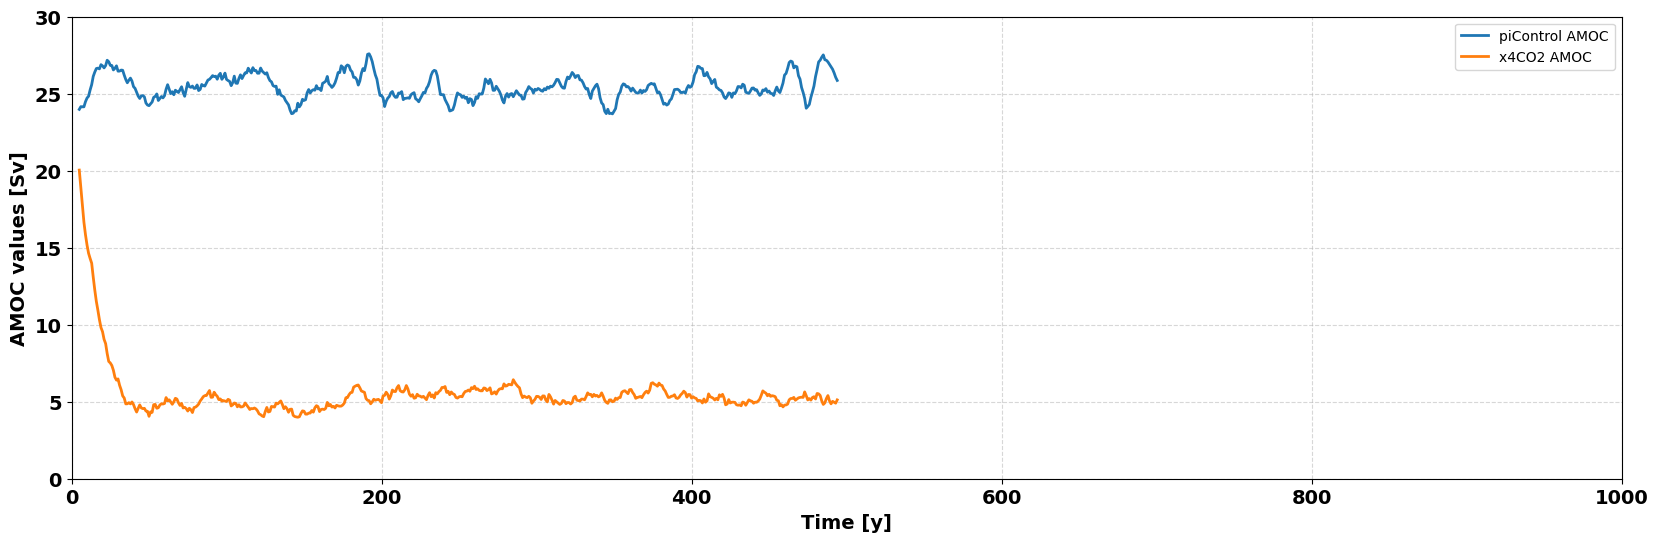

In [10]:
time_roll = np.arange(5, 495)

fig = plt.subplots(figsize=(20, 6))

plt.plot(time_roll, rolling_amoc_noresm_pi, color='tab:blue', linewidth=2, label='piControl AMOC')
plt.plot(time_roll, rolling_amoc_noresm_x4, color='tab:orange', linewidth=2, label='x4CO2 AMOC')

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('AMOC values [Sv]', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlim(0, 1000)
plt.ylim(0, 30)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc = 'upper right')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

### **1.5. Selecting the time slices for the lat-depth plots later on**

In [11]:
global_pi_0_30_noresm2 = (global_data_piControl_noresm2[0]['msftmz'].isel(year=slice(0,30))).mean(dim = 'year')/10**9

global_x4_120_150_noresm2 = (global_data_x4CO2_noresm2[0]['msftmz'].isel(year=slice(120,150))).mean(dim = 'year')/10**9
global_x4_470_500_noresm2 = (global_data_x4CO2_noresm2[0]['msftmz'].isel(year=slice(470,500))).mean(dim = 'year')/10**9

In [12]:
global_pi_0_30_noresm2 = global_pi_0_30_noresm2.values
global_x4_120_150_noresm2 = global_x4_120_150_noresm2.values
global_x4_470_500_noresm2 = global_x4_470_500_noresm2.values

In [13]:
save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/NorESM2-LM'

f_global_pi_0_30_noresm2 = f"{save_dir}/global_pi_0_30_noresm2.npy"
f_global_x4_120_150_noresm2 = f"{save_dir}/global_x4_120_150_noresm2.npy"
f_global_x4_470_500_noresm2 = f"{save_dir}/global_x4_470_500_noresm2.npy"

np.save(f_global_pi_0_30_noresm2, global_pi_0_30_noresm2)
np.save(f_global_x4_120_150_noresm2, global_x4_120_150_noresm2)
np.save(f_global_x4_470_500_noresm2, global_x4_470_500_noresm2)

## **2. Deacon cell**

### **2.1. Selecting the maximum values in the area between 60-40 S**

In [14]:
amoc_40S_pi_noresm2 = (global_data_piControl_noresm2[0]['msftmz'].sel(lat = slice(-60, -40), lev=slice(0, 1000))).max(dim={'lat', 'lev'}).values/10**9
amoc_40S_x4_noresm2 = (global_data_x4CO2_noresm2[0]['msftmz'].sel(lat = slice(-60, -40), lev=slice(0, 1000))).max(dim={'lat', 'lev'}).values/10**9

**For the timeseries anomalies, we subtract the mean of the entire piControl period from each x4CO2 year**

In [15]:
anom_SH_noresm2 = np.array([amoc_40S_x4_noresm2[i]-np.mean(amoc_40S_pi_noresm2) for i in range(0, 500)])

In [16]:
rolling_deac_noresm_pi = rolling_average_ts(amoc_40S_pi_noresm2, 11)
rolling_deac_noresm_x4 = rolling_average_ts(amoc_40S_x4_noresm2, 11)

rolling_deac_anom_noresm = rolling_average_ts(anom_SH_noresm2, 11)

In [17]:
save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/NorESM2-LM'

f_rolling_deac_noresm_pi = f"{save_dir}/rolling_deac_noresm_pi.npy"
f_rolling_deac_noresm_x4 = f"{save_dir}/rolling_deac_noresm_x4.npy"
f_rolling_deac_anom_noresm = f"{save_dir}/rolling_deac_anom_noresm.npy"

np.save(f_rolling_deac_noresm_pi, rolling_deac_noresm_pi)
np.save(f_rolling_deac_noresm_x4, rolling_deac_noresm_x4)
np.save(f_rolling_deac_anom_noresm, rolling_deac_anom_noresm)

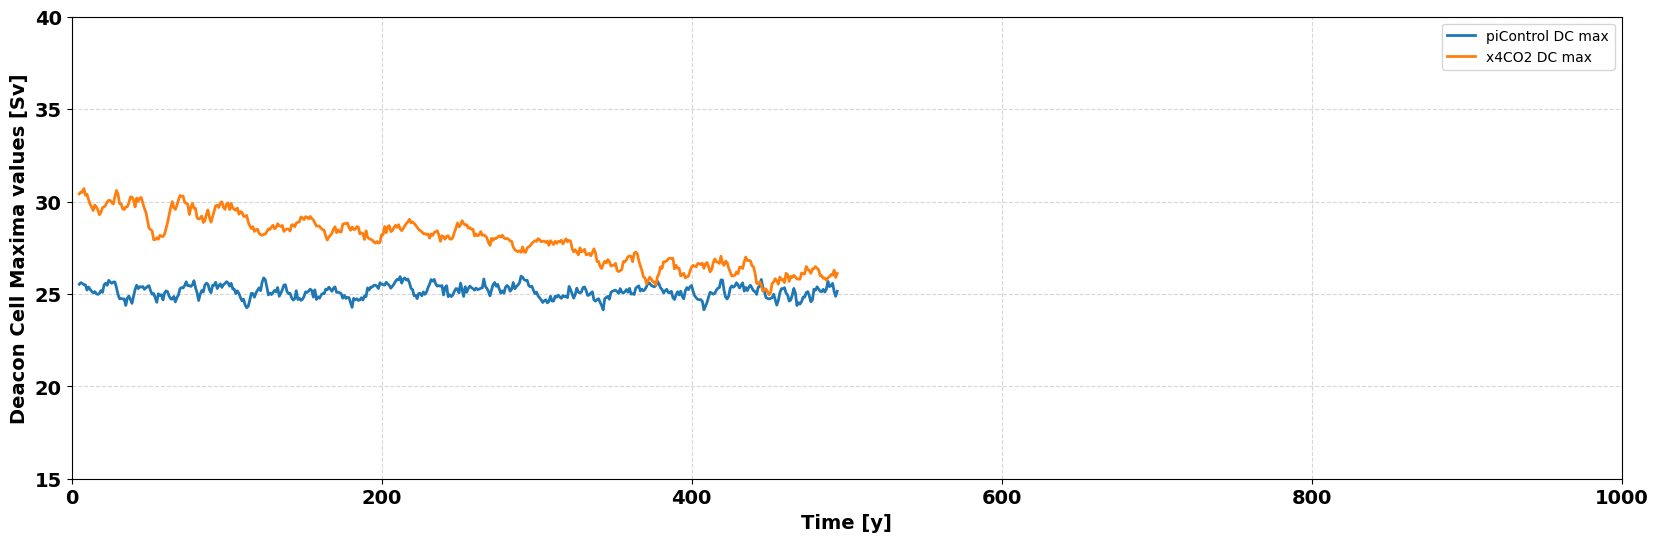

In [18]:
time_roll = np.arange(5, 495)

fig = plt.subplots(figsize=(20, 6))

plt.plot(time_roll, rolling_deac_noresm_pi, color='tab:blue', linewidth=2, label='piControl DC max')
plt.plot(time_roll, rolling_deac_noresm_x4, color='tab:orange', linewidth=2, label='x4CO2 DC max')

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Deacon Cell Maxima values [Sv]', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlim(0, 1000)
plt.ylim(15, 40)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc = 'upper right')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

### **3. Loading the data we saved**
*so we don't have to run the script every single time

In [2]:
load_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/NorESM2-LM'

# lev/lat
lev_noresm2 = np.load(f'{load_dir}/lev_noresm2.npy')
lat_noresm2 = np.load(f'{load_dir}/lat_noresm2.npy')

# amoc timeseries

rolling_amoc_noresm_pi = np.load(f'{load_dir}/rolling_amoc_noresm_pi.npy')
rolling_amoc_noresm_x4 = np.load(f'{load_dir}/rolling_amoc_noresm_x4.npy')
rolling_amoc_anom_noresm = np.load(f'{load_dir}/rolling_amoc_anom_noresm.npy')

# amoc map data

global_pi_0_30_noresm2 = np.load(f'/{load_dir}/global_pi_0_30_noresm2.npy')
global_x4_120_150_noresm2 = np.load(f'{load_dir}/global_x4_120_150_noresm2.npy')
global_x4_470_500_noresm2 = np.load(f'{load_dir}/global_x4_470_500_noresm2.npy')

# DC timeseries

rolling_deac_noresm_pi = np.load(f'{load_dir}/rolling_deac_noresm_pi.npy')
rolling_deac_noresm_x4 = np.load(f'{load_dir}/rolling_deac_noresm_x4.npy')
rolling_deac_anom_noresm = np.load(f'{load_dir}/rolling_deac_anom_noresm.npy')

# **B.CESM2**

**<span style="color:red">**Careful: depth levels in cm!!**</span>**

## **1. AMOC**

### **1.1. Getting the output data (msftmz) from NIRD**

In [20]:
experiments = ['piControl', 'abrupt-4xCO2']

msftmz_exp_cesm2 = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Omon/msftmz/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))

    yearly_msftmz = yearly_avg(ds)
    
    msftmz_exp_cesm2.append(yearly_msftmz)

**Getting the latitude and level values**

In [21]:
lev_cesm2 = (msftmz_exp_cesm2[0]['lev'].values) #in cm still!!
lat_cesm2 = msftmz_exp_cesm2[0]['lat'].values

save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/CESM2'

f_lev_cesm2 = f"{save_dir}/lev_cesm2.npy"
f_lat_cesm2 = f"{save_dir}/lat_cesm2.npy"

np.save(f_lev_cesm2, lev_cesm2)
np.save(f_lat_cesm2, lat_cesm2)

**Separating into piControl and x4CO2**

In [22]:
amoc_piControl_cesm2 = msftmz_exp_cesm2[0]
amoc_x4CO2_cesm2 = msftmz_exp_cesm2[1]

### **1.2. Getting the data for the Global Basin and for both experiments**

In [23]:
atlantic_data_piControl_cesm2, global_data_piControl_cesm2 = basin_separation_I(msftmz_exp_cesm2[0], "piControl", amoc_piControl_cesm2, 'CESM2')
atlantic_data_x4CO2_cesm2, global_data_x4CO2_cesm2 = basin_separation_I(msftmz_exp_cesm2[1], "x4CO2", amoc_x4CO2_cesm2, 'CESM2')

['atlantic_arctic_ocean', 'indian_pacific_ocean', 'global_ocean']
piControl Model model: Basin mapping -> {0: 'atlantic_arctic_ocean', 1: 'unknown_indian_pacific_ocean', 2: 'global_ocean'}

['atlantic_arctic_ocean', 'indian_pacific_ocean', 'global_ocean']
x4CO2 Model model: Basin mapping -> {np.int32(0): 'atlantic_arctic_ocean', np.int32(1): 'unknown_indian_pacific_ocean', np.int32(2): 'global_ocean'}



### **1.3. Calculating the MOC anomalies at 40 N**

In [24]:
amoc_40N_pi_cesm2 = (global_data_piControl_cesm2[0]['msftmz'].sel(lat = 40,  method="nearest")).max(dim='lev').values/10**9
amoc_40N_x4_cesm2 = (global_data_x4CO2_cesm2[0]['msftmz'].sel(lat = 40,  method="nearest")).max(dim='lev').values/10**9

In [25]:
anom_cesm2 = np.array([amoc_40N_x4_cesm2[i]-np.mean(amoc_40N_pi_cesm2) for i in range(0, 999)])

In [26]:
rolling_amoc_cesm_pi = rolling_average_ts(amoc_40N_pi_cesm2, 11)
rolling_amoc_cesm_x4 = rolling_average_ts(amoc_40N_x4_cesm2, 11)

rolling_amoc_anom_cesm = rolling_average_ts(anom_cesm2, 11)

In [27]:
save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/CESM2'

f_rolling_amoc_cesm_pi = f"{save_dir}/rolling_amoc_cesm_pi.npy"
f_rolling_amoc_cesm_x4 = f"{save_dir}/rolling_amoc_cesm_x4.npy"
f_rolling_amoc_anom_cesm = f"{save_dir}/rolling_amoc_anom_cesm.npy"

np.save(f_rolling_amoc_cesm_pi, rolling_amoc_cesm_pi)
np.save(f_rolling_amoc_cesm_x4, rolling_amoc_cesm_x4)
np.save(f_rolling_amoc_anom_cesm, rolling_amoc_anom_cesm)

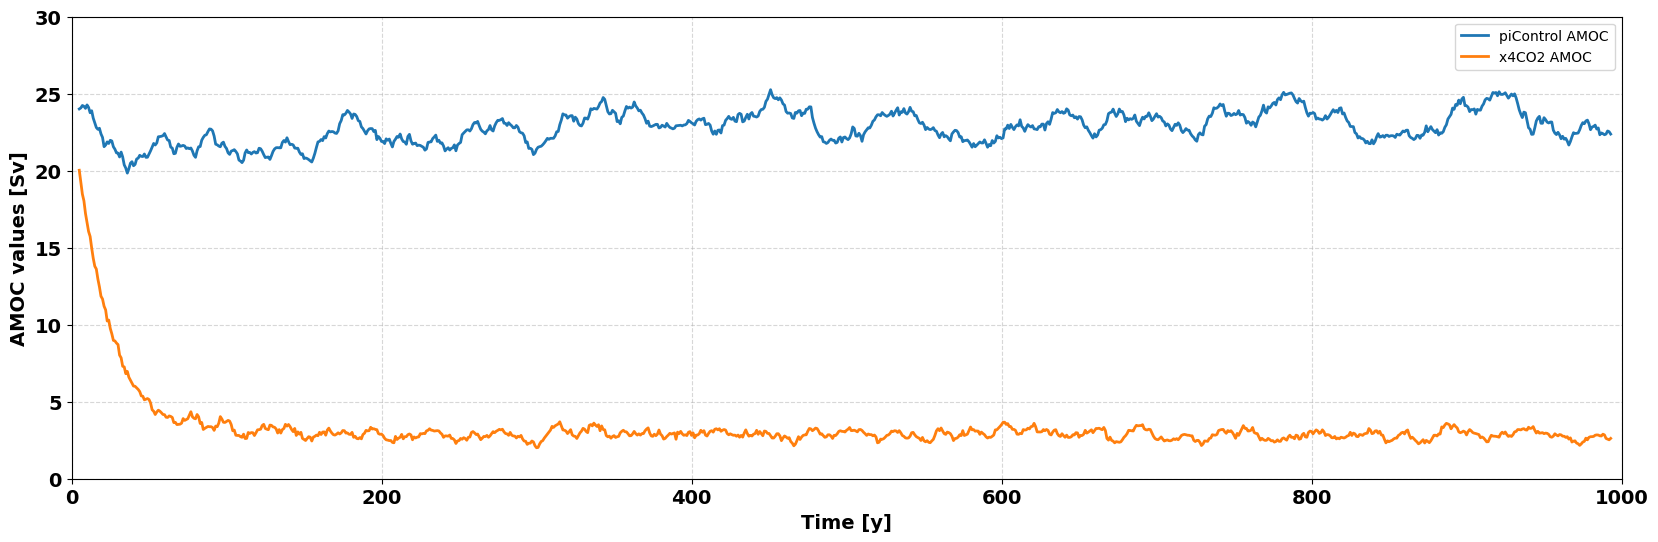

In [28]:
time_roll = np.arange(5, 994)

fig = plt.subplots(figsize=(20, 6))

plt.plot(time_roll, rolling_amoc_cesm_pi, color='tab:blue', linewidth=2, label='piControl AMOC')
plt.plot(time_roll, rolling_amoc_cesm_x4, color='tab:orange', linewidth=2, label='x4CO2 AMOC')

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('AMOC values [Sv]', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlim(0, 1000)
plt.ylim(0, 30)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc = 'upper right')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

### **1.5. Selecting the time slices for the lat-depth plots later on**

In [29]:
global_pi_0_30_cesm2 = (global_data_piControl_cesm2[0]['msftmz'].isel(year=slice(0,30))).mean(dim = 'year')/10**9

global_x4_120_150_cesm2 = (global_data_x4CO2_cesm2[0]['msftmz'].isel(year=slice(120,150))).mean(dim = 'year')/10**9
global_x4_470_500_cesm2 = (global_data_x4CO2_cesm2[0]['msftmz'].isel(year=slice(470,500))).mean(dim = 'year')/10**9
global_x4_870_900_cesm2 = (global_data_x4CO2_cesm2[0]['msftmz'].isel(year=slice(870,900))).mean(dim = 'year')/10**9
global_x4_970_999_cesm2 = (global_data_x4CO2_cesm2[0]['msftmz'].isel(year=slice(970,999))).mean(dim = 'year')/10**9

In [30]:
global_pi_0_30_cesm2 = global_pi_0_30_cesm2.values
global_x4_120_150_cesm2 = global_x4_120_150_cesm2.values
global_x4_470_500_cesm2 = global_x4_470_500_cesm2.values
global_x4_870_900_cesm2 = global_x4_870_900_cesm2.values
global_x4_970_999_cesm2 = global_x4_970_999_cesm2.values

In [31]:
save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/CESM2'

f_global_pi_0_30_cesm2 = f"{save_dir}/global_pi_0_30_cesm2.npy"
f_global_x4_120_150_cesm2 = f"{save_dir}/global_x4_120_150_cesm2.npy"
f_global_x4_470_500_cesm2 = f"{save_dir}/global_x4_470_500_cesm2.npy"
f_global_x4_870_900_cesm2 = f"{save_dir}/global_x4_870_900_cesm2.npy"
f_global_x4_970_999_cesm2 = f"{save_dir}/global_x4_970_999_cesm2.npy"

np.save(f_global_pi_0_30_cesm2, global_pi_0_30_cesm2)
np.save(f_global_x4_120_150_cesm2, global_x4_120_150_cesm2)
np.save(f_global_x4_470_500_cesm2, global_x4_470_500_cesm2)
np.save(f_global_x4_870_900_cesm2, global_x4_870_900_cesm2)
np.save(f_global_x4_970_999_cesm2, global_x4_970_999_cesm2)

## **2. Deacon cell**

### **2.1. Selecting the mximum values in the area between 60-40 S**

In [32]:
amoc_40S_pi_cesm2 = (global_data_piControl_cesm2[0]['msftmz'].sel(lat = slice(-60, -40), lev=slice(0, 1000*100))).max(dim={'lat', 'lev'}).values/10**9 #*100 to turn 1000m
                                                                                                                                                       # into cm
amoc_40S_x4_cesm2 = (global_data_x4CO2_cesm2[0]['msftmz'].sel(lat = slice(-60, -40), lev=slice(0, 1000*100))).max(dim={'lat', 'lev'}).values/10**9

**For the timeseries anomalies, we subtract the mean of the entire piControl period from each x4CO2 year**

In [33]:
anom_SH_cesm2 = np.array([amoc_40S_x4_cesm2[i]-np.mean(amoc_40S_pi_cesm2) for i in range(0, 999)])

In [34]:
rolling_deac_cesm_pi = rolling_average_ts(amoc_40S_pi_cesm2, 11)
rolling_deac_cesm_x4 = rolling_average_ts(amoc_40S_x4_cesm2, 11)

rolling_deac_anom_cesm = rolling_average_ts(anom_SH_cesm2, 11)

In [35]:
save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/CESM2'

f_rolling_deac_cesm_pi = f"{save_dir}/rolling_deac_cesm_pi.npy"
f_rolling_deac_cesm_x4 = f"{save_dir}/rolling_deac_cesm_x4.npy"
f_rolling_deac_anom_cesm = f"{save_dir}/rolling_deac_anom_cesm.npy"

np.save(f_rolling_deac_cesm_pi, rolling_deac_cesm_pi)
np.save(f_rolling_deac_cesm_x4, rolling_deac_cesm_x4)
np.save(f_rolling_deac_anom_cesm, rolling_deac_anom_cesm)

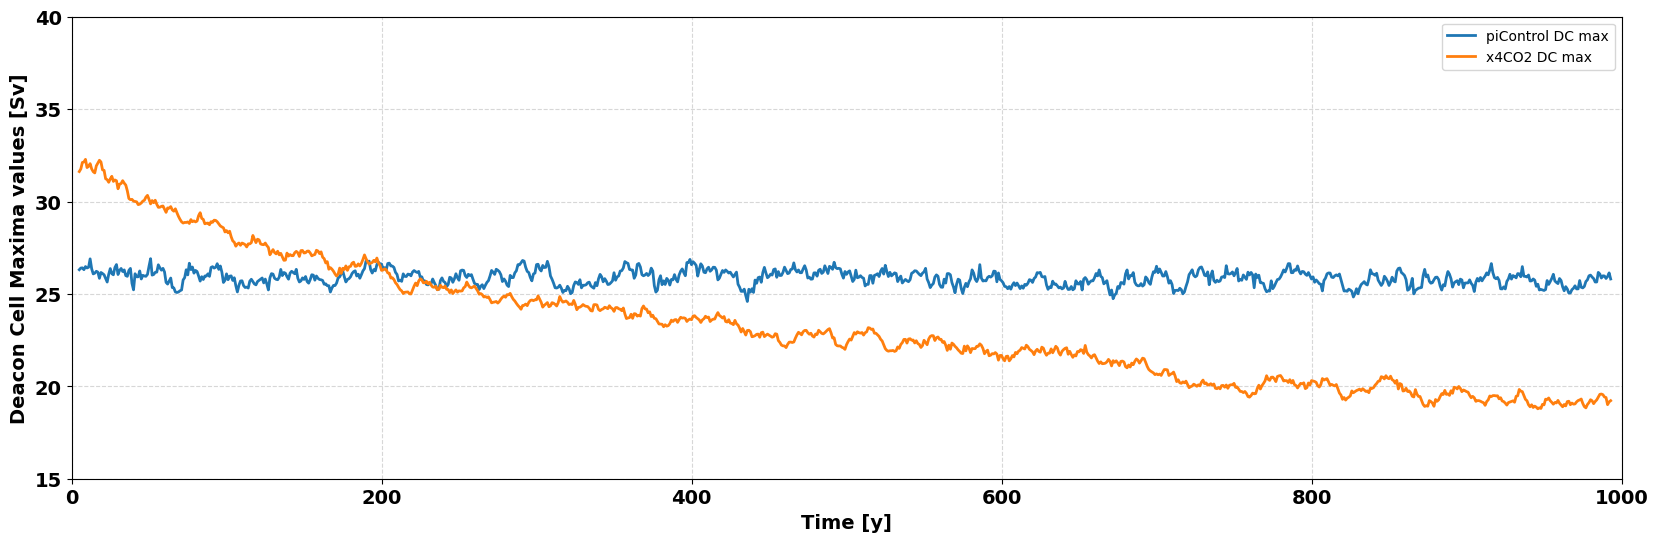

In [36]:
time_roll = np.arange(5, 994)

fig = plt.subplots(figsize=(20, 6))

plt.plot(time_roll, rolling_deac_cesm_pi, color='tab:blue', linewidth=2, label='piControl DC max')
plt.plot(time_roll, rolling_deac_cesm_x4, color='tab:orange', linewidth=2, label='x4CO2 DC max')

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Deacon Cell Maxima values [Sv]', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlim(0, 1000)
plt.ylim(15, 40)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc = 'upper right')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

### **3. Loading the data we saved**

In [3]:
load_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/CESM2'

# lev/lat
lev_cesm2 = np.load(f'{load_dir}/lev_cesm2.npy')
lat_cesm2 = np.load(f'{load_dir}/lat_cesm2.npy')

# amoc timeseries

rolling_amoc_cesm_pi = np.load(f'{load_dir}/rolling_amoc_cesm_pi.npy')
rolling_amoc_cesm_x4 = np.load(f'{load_dir}/rolling_amoc_cesm_x4.npy')
rolling_amoc_anom_cesm = np.load(f'{load_dir}/rolling_amoc_anom_cesm.npy')

# amoc map data

global_pi_0_30_cesm2 = np.load(f'/{load_dir}/global_pi_0_30_cesm2.npy')
global_x4_120_150_cesm2 = np.load(f'{load_dir}/global_x4_120_150_cesm2.npy')
global_x4_470_500_cesm2 = np.load(f'{load_dir}/global_x4_470_500_cesm2.npy')
global_x4_870_900_cesm2 = np.load(f'{load_dir}/global_x4_870_900_cesm2.npy')
global_x4_970_999_cesm2 = np.load(f'{load_dir}/global_x4_970_999_cesm2.npy')

# DC timeseries

rolling_deac_cesm_pi = np.load(f'{load_dir}/rolling_deac_cesm_pi.npy')
rolling_deac_cesm_x4 = np.load(f'{load_dir}/rolling_deac_cesm_x4.npy')
rolling_deac_anom_cesm = np.load(f'{load_dir}/rolling_deac_anom_cesm.npy')

# **C. IPSL-CM6A-LR**

## **1. AMOC**

### **1.1. Getting the output data (msftyz) from NIRD**

In [38]:
experiments = ['piControl', 'abrupt-4xCO2']

msftyz_exp_ipsl = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Omon/msftyz/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))
    ds['time'] = to_cftime(ds['time'].values)
    yearly_msftyz = yearly_avg(ds)
    
    msftyz_exp_ipsl.append(yearly_msftyz)

**Getting the latitude and level values**

In [39]:
lev_ipsl = msftyz_exp_ipsl[0]['olevel'].values
lat_ipsl = msftyz_exp_ipsl[0]['nav_lat'][:, 0].values

save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/IPSL-CM6A-LR'

f_lev_ipsl = f"{save_dir}/lev_ipsl.npy"
f_lat_ipsl = f"{save_dir}/lat_ipsl.npy"

np.save(f_lev_ipsl, lev_ipsl)
np.save(f_lat_ipsl, lat_ipsl)

**Separating into piControl and x4CO2**

In [40]:
amoc_piControl_ipsl = msftyz_exp_ipsl[0].rename({'3basin': 'basin'})
amoc_x4CO2_ipsl = msftyz_exp_ipsl[1].rename({'3basin': 'basin'})

### **1.2. Getting the data for the Global Basin and for both experiments**

In [41]:
global_data_piControl_ipsl = amoc_piControl_ipsl.isel(basin=0)
global_data_x4CO2_ipsl = amoc_x4CO2_ipsl.isel(basin=0)

### **1.3. Calculating the MOC anomalies at 40 N**

In [42]:
#picking up the index that gives latitude closer to 40N
lat = global_data_piControl_ipsl.nav_lat[:,0]       # (y,)
iy = abs(lat - 40).argmin().item()

amoc_40N_pi_ipsl = (global_data_piControl_ipsl['msftyz'].isel(y=iy, x=0)).max(dim='olevel').values/10**9
amoc_40N_x4_ipsl = (global_data_x4CO2_ipsl['msftyz'].isel(y=iy, x=0)).max(dim='olevel').values/10**9

**For the timeseries anomalies, we subtract the mean of the entire piControl period from each x4CO2 year**

In [43]:
anom_ipsl = np.array([amoc_40N_x4_ipsl[i]-np.mean(amoc_40N_pi_ipsl) for i in range(0, 900)])

In [44]:
rolling_amoc_ipsl_pi = rolling_average_ts(amoc_40N_pi_ipsl, 11)
rolling_amoc_ipsl_x4 = rolling_average_ts(amoc_40N_x4_ipsl, 11)

rolling_amoc_anom_ipsl = rolling_average_ts(anom_ipsl, 11)

In [45]:
save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/IPSL-CM6A-LR'

f_rolling_amoc_ipsl_pi = f"{save_dir}/rolling_amoc_ipsl_pi.npy"
f_rolling_amoc_ipsl_x4 = f"{save_dir}/rolling_amoc_ipsl_x4.npy"
f_rolling_amoc_anom_ipsl = f"{save_dir}/rolling_amoc_anom_ipsl.npy"

np.save(f_rolling_amoc_ipsl_pi, rolling_amoc_ipsl_pi)
np.save(f_rolling_amoc_ipsl_x4, rolling_amoc_ipsl_x4)
np.save(f_rolling_amoc_anom_ipsl, rolling_amoc_anom_ipsl)

### **1.4. Plotting the x4CO2 and piControl timeseries**

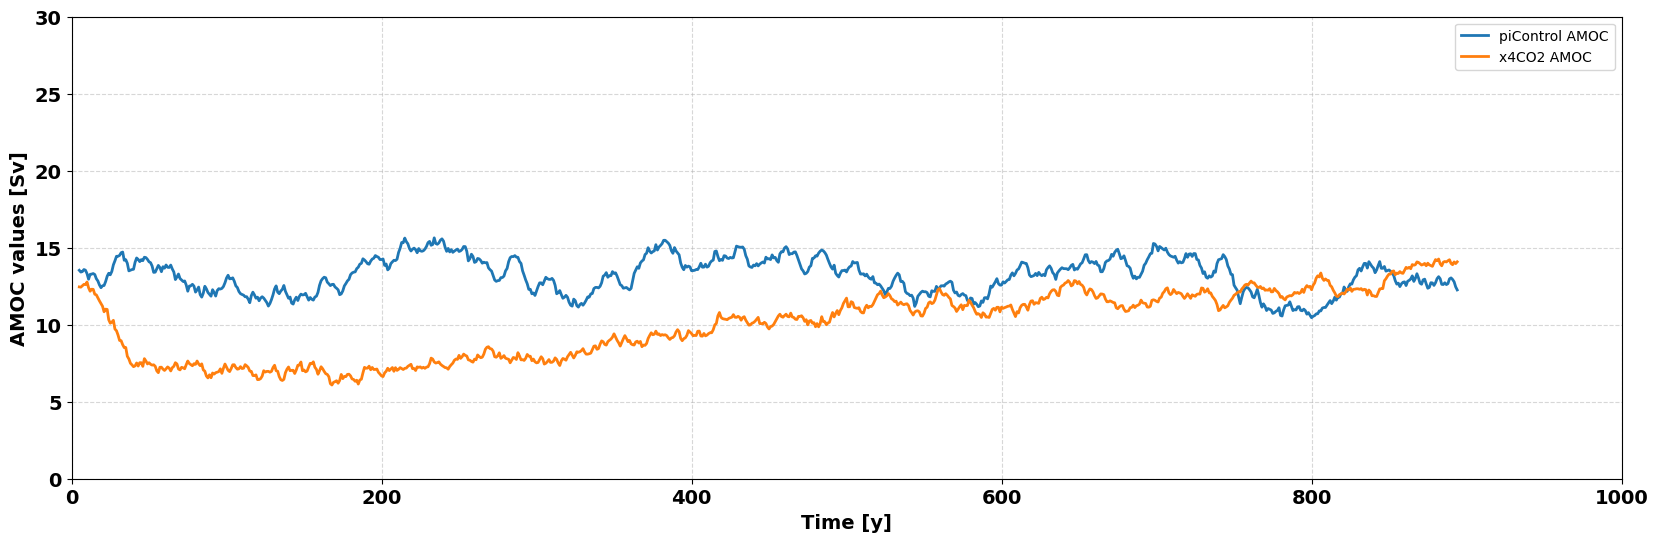

In [46]:
time_roll = np.arange(5, 895)

fig = plt.subplots(figsize=(20, 6))

plt.plot(time_roll, rolling_amoc_ipsl_pi, color='tab:blue', linewidth=2, label='piControl AMOC')
plt.plot(time_roll, rolling_amoc_ipsl_x4, color='tab:orange', linewidth=2, label='x4CO2 AMOC')

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('AMOC values [Sv]', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlim(0, 1000)
plt.ylim(0, 30)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc = 'upper right')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

### **1.5. Selecting the time slices for the lat-depth plots later on**

In [47]:
global_pi_0_30_ipsl = (global_data_piControl_ipsl['msftyz'].squeeze().isel(year=slice(0,30))).mean(dim = 'year')/10**9

global_x4_120_150_ipsl = (global_data_x4CO2_ipsl['msftyz'].squeeze().isel(year=slice(120,150))).mean(dim = 'year')/10**9
global_x4_470_500_ipsl = (global_data_x4CO2_ipsl['msftyz'].squeeze().isel(year=slice(470,500))).mean(dim = 'year')/10**9
global_x4_870_900_ipsl = (global_data_x4CO2_ipsl['msftyz'].squeeze().isel(year=slice(870,900))).mean(dim = 'year')/10**9

In [48]:
global_pi_0_30_ipsl = global_pi_0_30_ipsl.values
global_x4_120_150_ipsl = global_x4_120_150_ipsl.values
global_x4_470_500_ipsl = global_x4_470_500_ipsl.values
global_x4_870_900_ipsl = global_x4_870_900_ipsl.values

In [49]:
save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/IPSL-CM6A-LR'

f_global_pi_0_30_ipsl = f"{save_dir}/global_pi_0_30_ipsl.npy"
f_global_x4_120_150_ipsl = f"{save_dir}/global_x4_120_150_ipsl.npy"
f_global_x4_470_500_ipsl = f"{save_dir}/global_x4_470_500_ipsl.npy"
f_global_x4_870_900_ipsl = f"{save_dir}/global_x4_870_900_ipsl.npy"

np.save(f_global_pi_0_30_ipsl, global_pi_0_30_ipsl)
np.save(f_global_x4_120_150_ipsl, global_x4_120_150_ipsl)
np.save(f_global_x4_470_500_ipsl, global_x4_470_500_ipsl)
np.save(f_global_x4_870_900_ipsl, global_x4_870_900_ipsl)

## **2. Deacon cell**

### **2.1. Selecting the maximum values in the area between 60-40 S**

In [50]:
iy_40 = abs(lat + 40).argmin().item()
iy_60 = abs(lat + 60).argmin().item()

olevel = global_data_piControl_ipsl['msftyz']['olevel'].values

ilev_0 = abs(olevel -0).argmin().item()
ilev_1000 = abs(olevel -1000).argmin().item()


amoc_40S_pi_ipsl = (global_data_piControl_ipsl['msftyz'].isel(y = slice(iy_60, iy_40), x=0, olevel=slice(ilev_0, ilev_1000))).max(dim={'y', 'olevel'}).values/10**9

amoc_40S_x4_ipsl = (global_data_x4CO2_ipsl['msftyz'].isel(y = slice(iy_60, iy_40), x=0, olevel=slice(ilev_0, ilev_1000))).max(dim={'y', 'olevel'}).values/10**9

**For the timeseries anomalies, we subtract the mean of the entire piControl period from each x4CO2 year**

In [51]:
anom_SH_ipsl =  np.array([amoc_40S_x4_ipsl[i]-np.mean(amoc_40S_pi_ipsl) for i in range(0, 900)])

In [52]:
rolling_deac_ipsl_pi = rolling_average_ts(amoc_40S_pi_ipsl, 11)
rolling_deac_ipsl_x4 = rolling_average_ts(amoc_40S_x4_ipsl, 11)

rolling_deac_anom_ipsl = rolling_average_ts(anom_SH_ipsl, 11)

In [53]:
save_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/IPSL-CM6A-LR'

f_rolling_deac_ipsl_pi = f"{save_dir}/rolling_deac_ipsl_pi.npy"
f_rolling_deac_ipsl_x4 = f"{save_dir}/rolling_deac_ipsl_x4.npy"
f_rolling_deac_anom_ipsl = f"{save_dir}/rolling_deac_anom_ipsl.npy"

np.save(f_rolling_deac_ipsl_pi, rolling_deac_ipsl_pi)
np.save(f_rolling_deac_ipsl_x4, rolling_deac_ipsl_x4)
np.save(f_rolling_deac_anom_ipsl, rolling_deac_anom_ipsl)

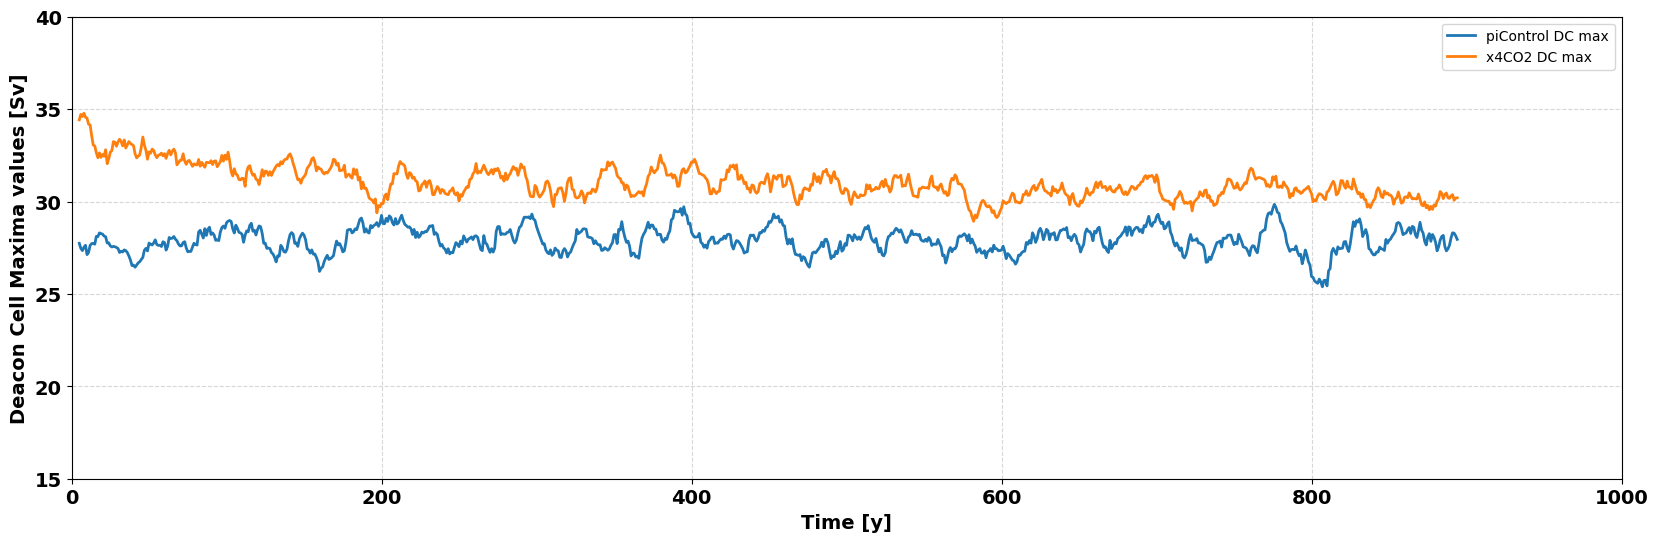

In [16]:
time_roll = np.arange(5, 895)

fig = plt.subplots(figsize=(20, 6))

plt.plot(time_roll, rolling_deac_ipsl_pi, color='tab:blue', linewidth=2, label='piControl DC max')
plt.plot(time_roll, rolling_deac_ipsl_x4, color='tab:orange', linewidth=2, label='x4CO2 DC max')

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Deacon Cell Maxima values [Sv]', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlim(0, 1000)
plt.ylim(15, 40)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc = 'upper right')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

### **3. Loading the data we saved**

In [4]:
load_dir = '/nird/home/chrikap/AMOC_script_Ada/AMOC_data/IPSL-CM6A-LR'

# lev/lat
lev_ipsl = np.load(f'{load_dir}/lev_ipsl.npy')
lat_ipsl = np.load(f'{load_dir}/lat_ipsl.npy')

# amoc timeseries

rolling_amoc_ipsl_pi = np.load(f'{load_dir}/rolling_amoc_ipsl_pi.npy')
rolling_amoc_ipsl_x4 = np.load(f'{load_dir}/rolling_amoc_ipsl_x4.npy')
rolling_amoc_anom_ipsl = np.load(f'{load_dir}/rolling_amoc_anom_ipsl.npy')

# amoc map data

global_pi_0_30_ipsl = np.load(f'/{load_dir}/global_pi_0_30_ipsl.npy')
global_x4_120_150_ipsl = np.load(f'{load_dir}/global_x4_120_150_ipsl.npy')
global_x4_470_500_ipsl = np.load(f'{load_dir}/global_x4_470_500_ipsl.npy')
global_x4_870_900_ipsl = np.load(f'{load_dir}/global_x4_870_900_ipsl.npy')

# DC timeseries

rolling_deac_ipsl_pi = np.load(f'{load_dir}/rolling_deac_ipsl_pi.npy')
rolling_deac_ipsl_x4 = np.load(f'{load_dir}/rolling_deac_ipsl_x4.npy')
rolling_deac_anom_ipsl = np.load(f'{load_dir}/rolling_deac_anom_ipsl.npy')

# **Alternative plotting**

In [5]:
def nearest_levels(data, target_levels):
    data_vals = np.unique(data[~np.isnan(data)])
    return np.array([
        data_vals[np.argmin(np.abs(data_vals - lvl))]
        for lvl in target_levels
    ])

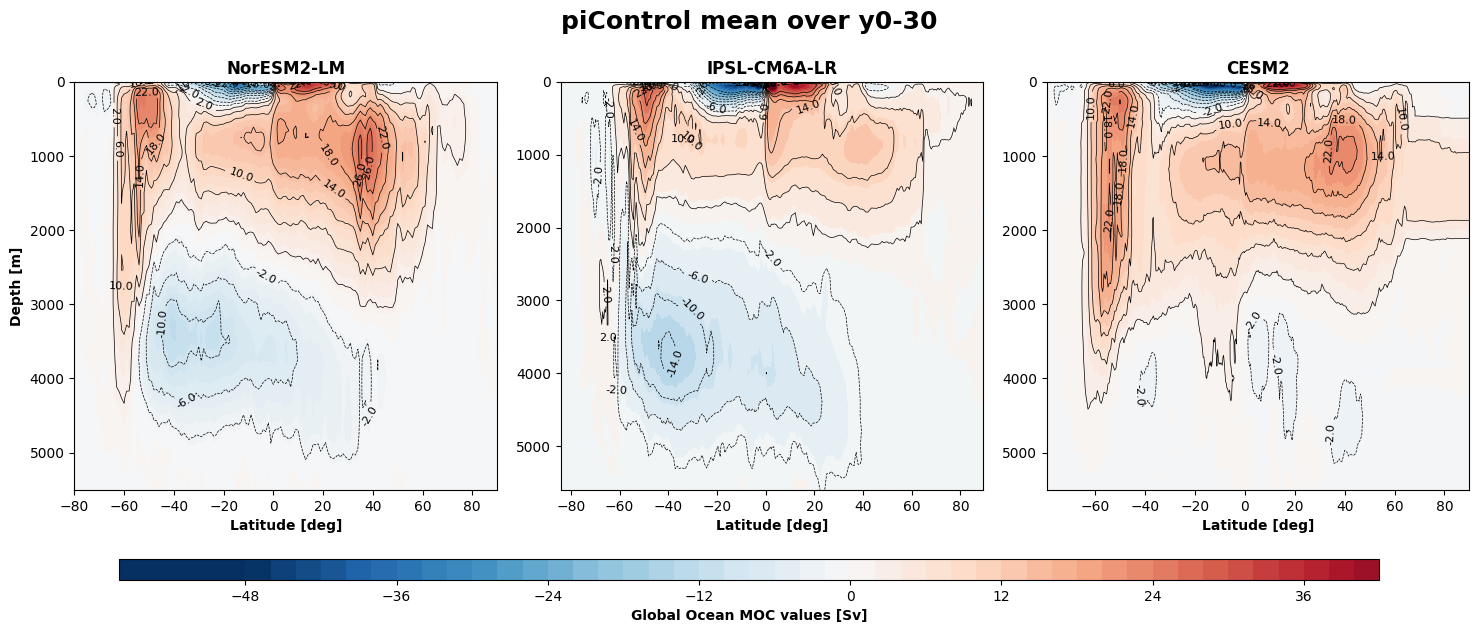

In [28]:
data_piControl_list = [global_pi_0_30_noresm2[:-5, :], global_pi_0_30_ipsl[:-1, :], global_pi_0_30_cesm2]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]
target_levels = np.arange(-30, 30, 4)

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i, data_piControl in enumerate(data_piControl_list):

    if titles[i]== "NorESM2-LM":        

        lat = lat_noresm2
        lev = lev_noresm2[:-5]

    elif titles[i]== "CESM2":        

        lat = lat_cesm2
        lev = lev_cesm2/100

    else:
        lat = lat_ipsl
        lev = lev_ipsl[:-1]
        
    data = data_piControl

    # Plot
    ax = fig.add_subplot(gs[0, i])

    im_pi = ax.contourf(
        lat, lev,
        data,
        levels=60,
        cmap="RdBu_r",
        vmin=-48, vmax=48
    )

    levels = np.unique(nearest_levels(data, target_levels))

    neg_levels = levels[levels < 0]
    pos_levels = levels[levels > 0]

    # Negative contours (dashed)
    pi_neg = ax.contour(lat, lev,
        (data),
        levels=neg_levels,
        colors='k',
        linestyles='dashed',
        linewidths=0.5
    )
    
    # Positive contours (solid)
    pi_pos = ax.contour(lat, lev,
        (data),
        levels=pos_levels,
        colors='k',
        linestyles='solid',
        linewidths=0.5
    )
    ax.set_title(titles[i], fontweight='bold')
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel("Depth [m]", fontweight="bold")

    # Add x-label to all panels
    ax.set_xlabel("Latitude [deg]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im_pi, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Global Ocean MOC values [Sv]", fontweight='bold')

fig.suptitle("piControl mean over y0-30", fontsize=18, weight='bold', y=1)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

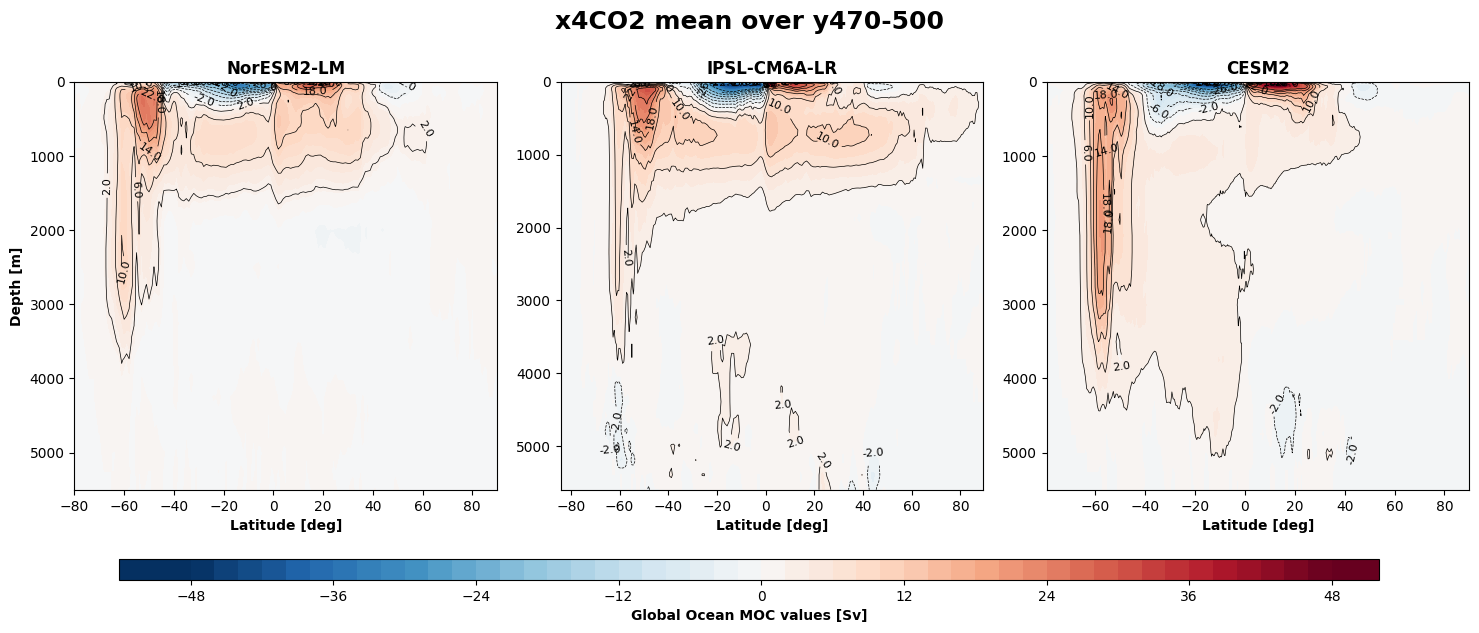

In [29]:
data_x4CO2_list = [global_x4_470_500_noresm2[:-5, :], global_x4_470_500_ipsl[:-1, :], global_x4_470_500_cesm2]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]
target_levels = np.arange(-30, 30, 4)

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i, data_x4CO2 in enumerate(data_x4CO2_list):

    if titles[i]== "NorESM2-LM":        

        lat = lat_noresm2
        lev = lev_noresm2[:-5]

    elif titles[i]== "CESM2":        

        lat = lat_cesm2
        lev = lev_cesm2/100

    else:
        lat = lat_ipsl
        lev = lev_ipsl[:-1]
        
    data = data_x4CO2

    # Plot
    ax = fig.add_subplot(gs[0, i])

    im_pi = ax.contourf(
        lat, lev,
        data,
        levels=60,
        cmap="RdBu_r",
        vmin=-48, vmax=48
    )

    levels = np.unique(nearest_levels(data, target_levels))
    neg_levels = levels[levels < 0]
    pos_levels = levels[levels > 0]

    # Negative contours (dashed)
    pi_neg = ax.contour(lat, lev,
        (data),
        levels=neg_levels,
        colors='k',
        linestyles='dashed',
        linewidths=0.5
    )
    
    # Positive contours (solid)
    pi_pos = ax.contour(lat, lev,
        (data),
        levels=pos_levels,
        colors='k',
        linestyles='solid',
        linewidths=0.5
    )
    ax.set_title(titles[i], fontweight='bold')
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel("Depth [m]", fontweight="bold")

    # Add x-label to all panels
    ax.set_xlabel("Latitude [deg]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im_pi, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Global Ocean MOC values [Sv]", fontweight='bold')

fig.suptitle("x4CO2 mean over y470-500", fontsize=18, weight='bold', y=1)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

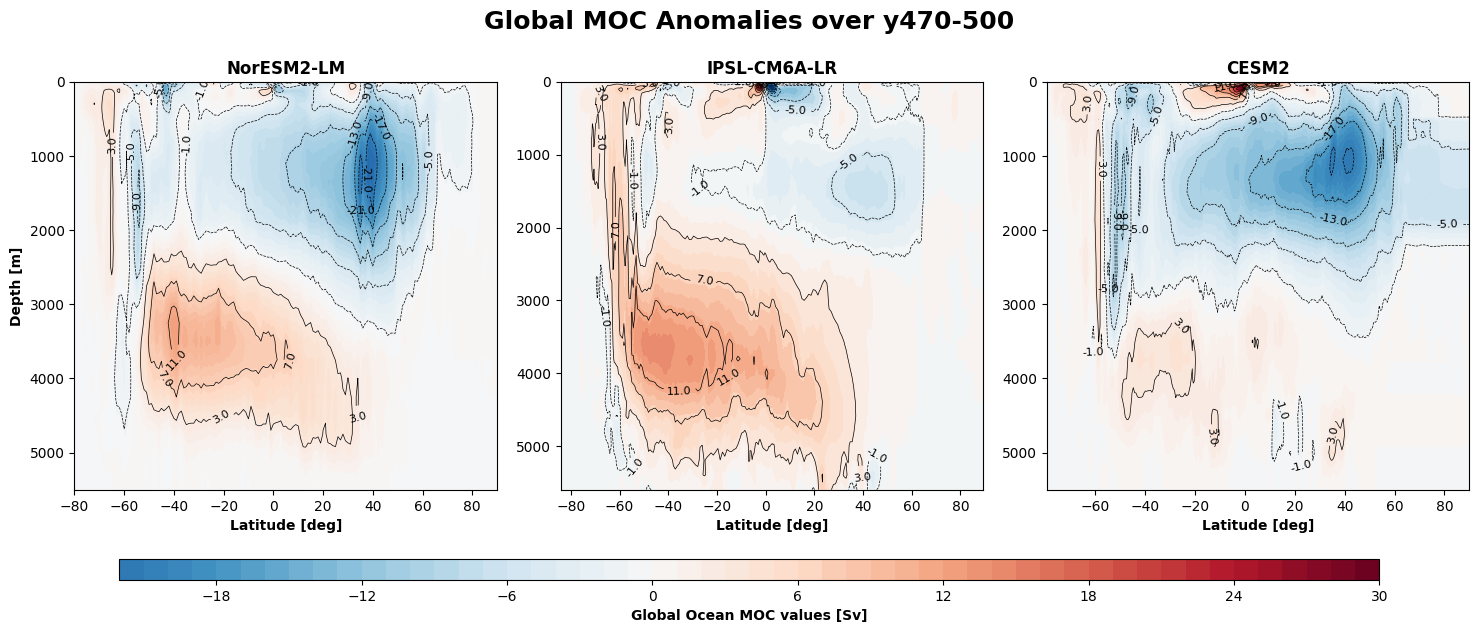

In [36]:
anom_noresm2 = global_x4_470_500_noresm2 - global_pi_0_30_noresm2
anom_ipsl = global_x4_470_500_ipsl - global_pi_0_30_ipsl
anom_cesm2 = global_x4_470_500_cesm2 - global_pi_0_30_cesm2

data_anom_list = [anom_noresm2[:-5, :], anom_ipsl[:-1, :], anom_cesm2]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]
target_levels = np.arange(-25, 25, 4)

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i, data_anom in enumerate(data_anom_list):

    if titles[i]== "NorESM2-LM":        

        lat = lat_noresm2
        lev = lev_noresm2[:-5]

    elif titles[i]== "CESM2":        

        lat = lat_cesm2
        lev = lev_cesm2/100

    else:
        lat = lat_ipsl
        lev = lev_ipsl[:-1]
        
    data = data_anom

    # Plot
    ax = fig.add_subplot(gs[0, i])

    im_pi = ax.contourf(
        lat, lev,
        data,
        levels=60,
        cmap="RdBu_r",
        vmin=-30, vmax=30
    )

    levels = np.unique(nearest_levels(data, target_levels))
    neg_levels = levels[levels < 0]
    pos_levels = levels[levels > 0]

    # Negative contours (dashed)
    pi_neg = ax.contour(lat, lev,
        (data),
        levels=neg_levels,
        colors='k',
        linestyles='dashed',
        linewidths=0.5
    )
    
    # Positive contours (solid)
    pi_pos = ax.contour(lat, lev,
        (data),
        levels=pos_levels,
        colors='k',
        linestyles='solid',
        linewidths=0.5
    )
    ax.set_title(titles[i], fontweight='bold')
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel("Depth [m]", fontweight="bold")

    # Add x-label to all panels
    ax.set_xlabel("Latitude [deg]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im_pi, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Global Ocean MOC values [Sv]", fontweight='bold')

fig.suptitle("Global MOC Anomalies over y470-500", fontsize=18, weight='bold', y=1)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

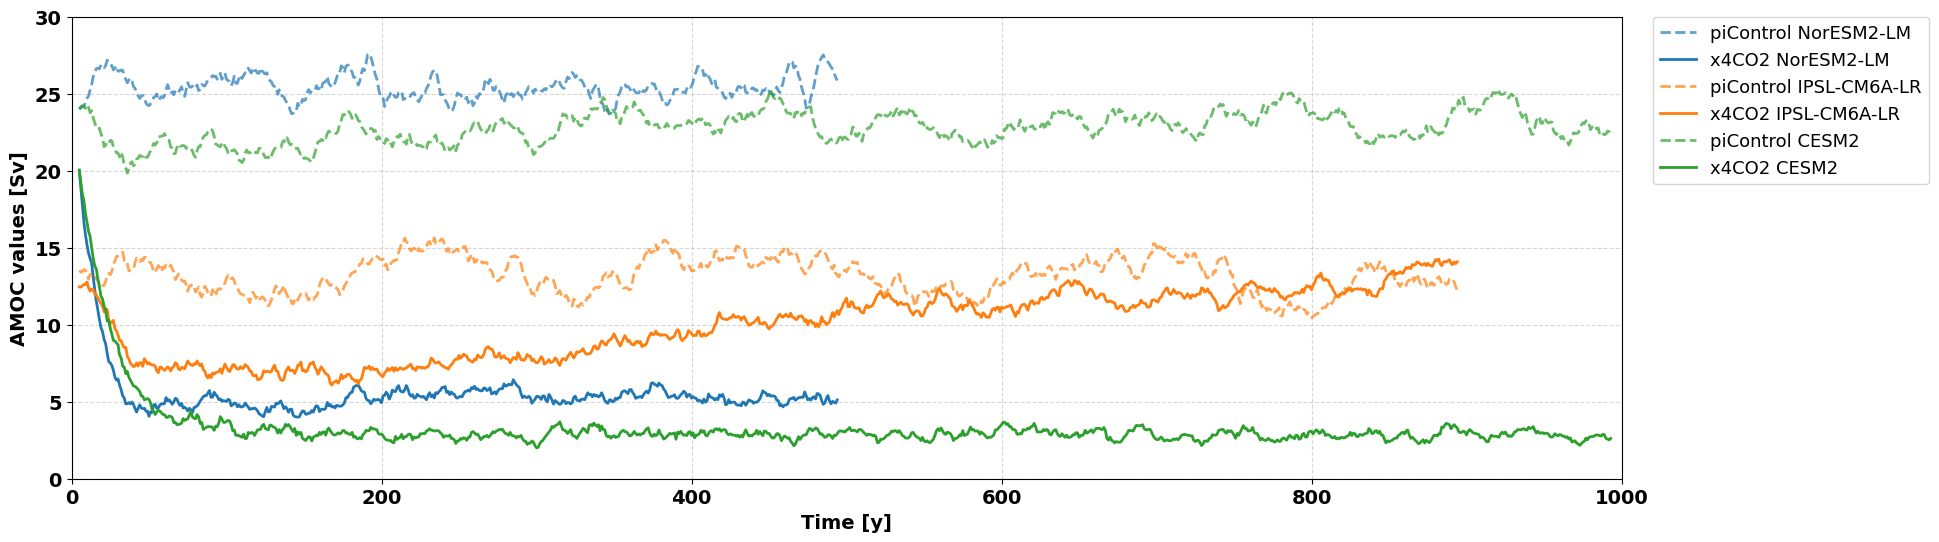

In [34]:
time_roll_noresm2 = np.arange(5, 495)
time_roll_ipsl = np.arange(5, 895)
time_roll_cesm2 = np.arange(5, 994)

fig = plt.subplots(figsize=(20, 6))

plt.plot(time_roll_noresm2, rolling_amoc_noresm_pi, '--', color='tab:blue', alpha = 0.7, linewidth=2, label='piControl NorESM2-LM')
plt.plot(time_roll_noresm2, rolling_amoc_noresm_x4, color='tab:blue', linewidth=2, label='x4CO2 NorESM2-LM')

plt.plot(time_roll_ipsl, rolling_amoc_ipsl_pi, '--', color='tab:orange',  alpha = 0.7, linewidth=2, label='piControl IPSL-CM6A-LR')
plt.plot(time_roll_ipsl, rolling_amoc_ipsl_x4, color='tab:orange', linewidth=2, label='x4CO2 IPSL-CM6A-LR')

plt.plot(time_roll_cesm2, rolling_amoc_cesm_pi, '--', color='tab:green', alpha = 0.7, linewidth=2, label='piControl CESM2')
plt.plot(time_roll_cesm2, rolling_amoc_cesm_x4, color='tab:green', linewidth=2, label='x4CO2 CESM2')

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('AMOC values [Sv]', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlim(0, 1000)
plt.ylim(0, 30)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
#plt.legend(loc = 'upper right')
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    fontsize=13
)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

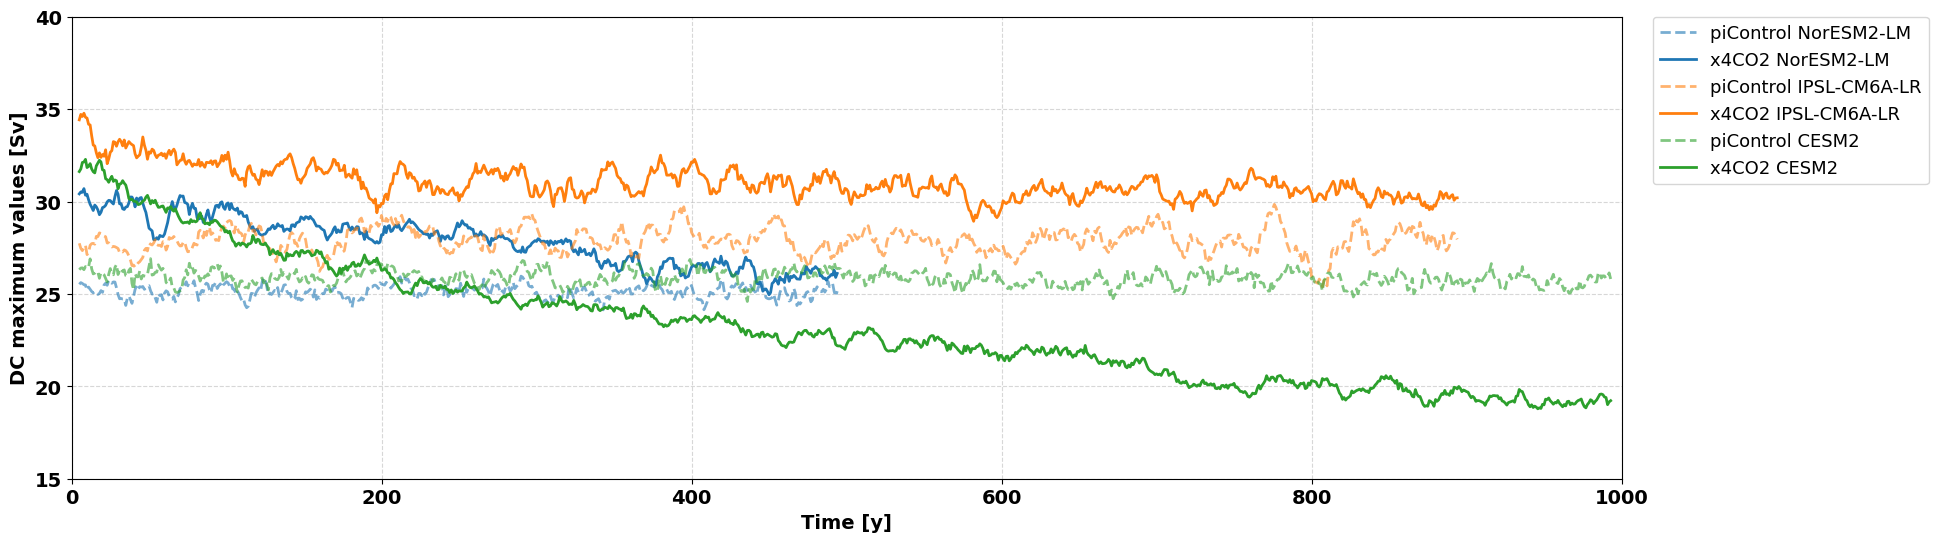

In [21]:
time_roll_noresm2 = np.arange(5, 495)
time_roll_ipsl = np.arange(5, 895)
time_roll_cesm2 = np.arange(5, 994)

fig = plt.subplots(figsize=(20, 6))

plt.plot(time_roll_noresm2, rolling_deac_noresm_pi, '--', color='tab:blue', alpha = 0.6, linewidth=2, label='piControl NorESM2-LM')
plt.plot(time_roll_noresm2, rolling_deac_noresm_x4, color='tab:blue', linewidth=2, label='x4CO2 NorESM2-LM')

plt.plot(time_roll_ipsl, rolling_deac_ipsl_pi, '--', color='tab:orange',  alpha = 0.6, linewidth=2, label='piControl IPSL-CM6A-LR')
plt.plot(time_roll_ipsl, rolling_deac_ipsl_x4, color='tab:orange', linewidth=2, label='x4CO2 IPSL-CM6A-LR')

plt.plot(time_roll_cesm2, rolling_deac_cesm_pi, '--', color='tab:green', alpha = 0.6, linewidth=2, label='piControl CESM2')
plt.plot(time_roll_cesm2, rolling_deac_cesm_x4, color='tab:green', linewidth=2, label='x4CO2 CESM2')

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('DC maximum values [Sv]', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlim(0, 1000)
plt.ylim(15, 40)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
#plt.legend(loc = 'upper right')
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    fontsize=13
)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()